🍷 Project: Dimensionality Reduction with PCA
```
Our learning roadmap
Wine Dataset
     ↓
Understand Dimensions
     ↓
EDA
     ↓
Train/Test Split
     ↓
Feature Scaling
     ↓
Why Dimensionality Reduction?
     ↓
PCA
     ↓
Principal Components
     ↓
Explained Variance
     ↓
Scree Plot ⭐
     ↓
Cumulative Explained Variance
     ↓
Choose Number of Components
     ↓
Transform Dataset
     ↓
Visualize in 2D
     ↓
Train ML Model
     ↓
Compare Before vs After PCA
     ↓
Final Understanding
What we'll answer during the project

By the end, you should be able to answer these without memorizing definitions:

What is dimensionality?
Why do we need dimensionality reduction?
What exactly does PCA do?
Why does PCA require scaling?
What is a principal component?
What does PC1 actually mean?
What is explained variance?
What is a Scree plot?
How do we decide how many components to keep?
What information do we lose after PCA?
Why can PCA improve some ML models but hurt others?
How do we visualize high-dimensional data using PCA?

In [3]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["Target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


What happened here?

load_wine() gives us the Wine dataset.
```
The dataset contains:

178 observations
13 numerical features
3 target classes

The 13 features include things such as:

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline

So our dataset looks conceptually like:

                 13 FEATURES
                     ↓
       ┌───────────────────────────┐
       │ Alcohol                   │
       │ Malic acid                │
       │ Ash                       │
       │ Magnesium                 │
       │ ...                       │
       │ Proline                   │
       └───────────────────────────┘
                     ↓
                 Target
               Class 0/1/2

And this is where dimensionality comes in.

Our dataset currently has:

13 dimensions

because every observation is represented using 13 features.

For example, one wine could be represented as:

Wine #1

[14.23, 1.71, 2.43, 15.6, 127, ... , 3.92, 1065]

That's a point in 13-dimensional space.

Humans, inconveniently, are much better at seeing 2D and 3D than 13D.

That's one reason dimensionality reduction becomes useful.

In [4]:
df.shape

(178, 14)

13 → input features
,1  → Target
--------------
```
14 → total columns

So for PCA, we do not want the Target column.

Why?

Because Target tells us the answer/class of the wine. PCA should work only on the input features.

So conceptually:

                 DATASET
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
      Features              Target
       13 cols                1 col
          │                   │
          │                   └── Used later for ML/evaluation
          ↓
         PCA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Notice something?

The scales are VERY different.
```
For example:

alcohol       → around 11–15

malic_acid    → around 0.7–5.8

magnesium     → around 70–162

proline       → around 278–1680

This is going to become extremely important when we perform PCA.
_________________________________________________________________

4. Why should we care about different scales?

Imagine we have only two features:

Feature A: Age
Feature B: Salary

Suppose:

Age     = 20–60
Salary  = 20,000–2,00,000

If PCA looks at the raw values, the salary feature has numbers that are enormously larger.

So it can have a much bigger influence on the calculation.

We don't want:

"Salary has large numbers, therefore salary wins PCA."

That's not meaningful.

We want the features to be put onto a comparable scale first.

That's why we'll use:

StandardScaler

before PCA.

In [8]:
df['Target'].value_counts()

Target
1    71
0    59
2    48
Name: count, dtype: int64

5. Target distribution
```
You got:

Target
1    71
0    59
2    48

Total:

71 + 59 + 48 = 178

So there are three wine classes:

Class 0 → 59
Class 1 → 71
Class 2 → 48

Notice that they're not perfectly balanced, but they're reasonably distributed.

# Now let's separate x and y

In [9]:
x = df.drop('Target', axis=1)
y = df['Target']

In [10]:
x.shape

(178, 13)

In [11]:
y.shape

(178,)

So we now have:
```
X
│
├── alcohol
├── malic_acid
├── ash
├── alcalinity_of_ash
├── magnesium
├── total_phenols
├── flavanoids
├── nonflavanoid_phenols
├── proanthocyanins
├── color_intensity
├── hue
├── od280/od315_of_diluted_wines
└── proline

and:

y
│
└── Target
      ├── 0
      ├── 1
      └── 2

# Step 3: Visualize the features

Before we touch PCA, let's actually look at the data.

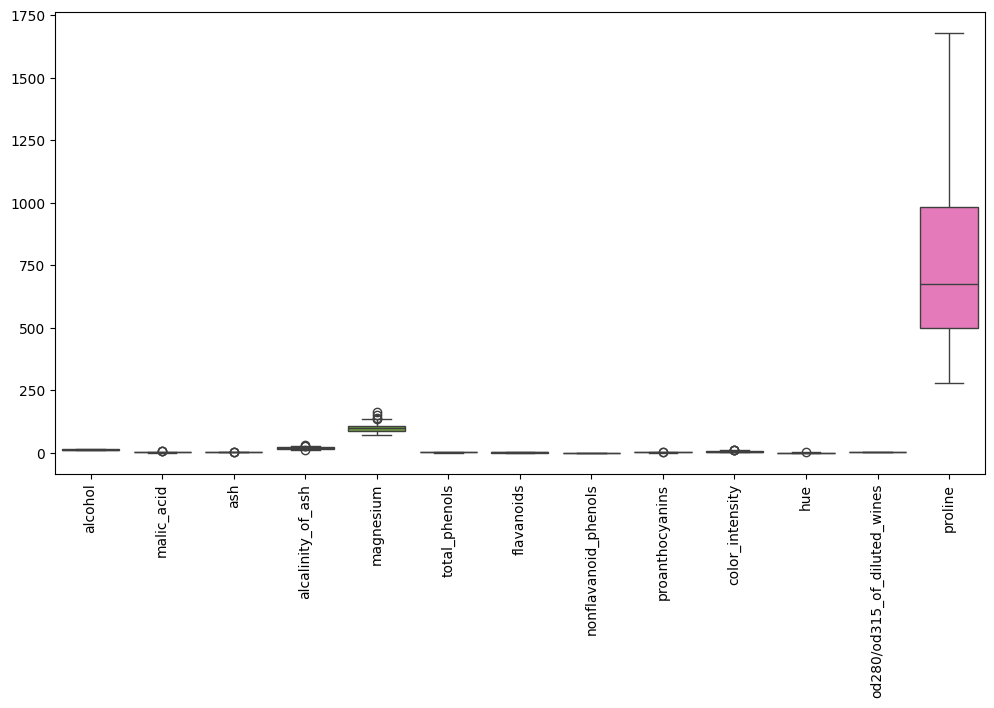

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=x)
plt.xticks(rotation=90)
plt.show()

The most obvious feature is:
```
proline

Its values are roughly:

278 → 1680

while some other features are around:

0 → 5
0 → 15
0 → 3

So the features are on very different scales.

For example:

alcohol       ≈ 11–15
malic_acid    ≈ 0.7–5.8
magnesium     ≈ 70–162
proline       ≈ 278–1680

This matters enormously for PCA.

Imagine PCA without scaling

Suppose PCA is looking at:

alcohol = 13
proline = 700

The numerical variation in proline is much larger.

PCA is based on variance, and variance depends on the scale of the values.

So a feature with a huge numerical scale can dominate the variance calculation.

We don't want PCA thinking:

"PROLINE HAS BIG NUMBERS. THEREFORE PROLINE MUST BE THE MOST IMPORTANT FEATURE."

That would be a rather stupid way to do dimensionality reduction.

So before PCA:

Original data
      ↓
Standardization
      ↓
PCA

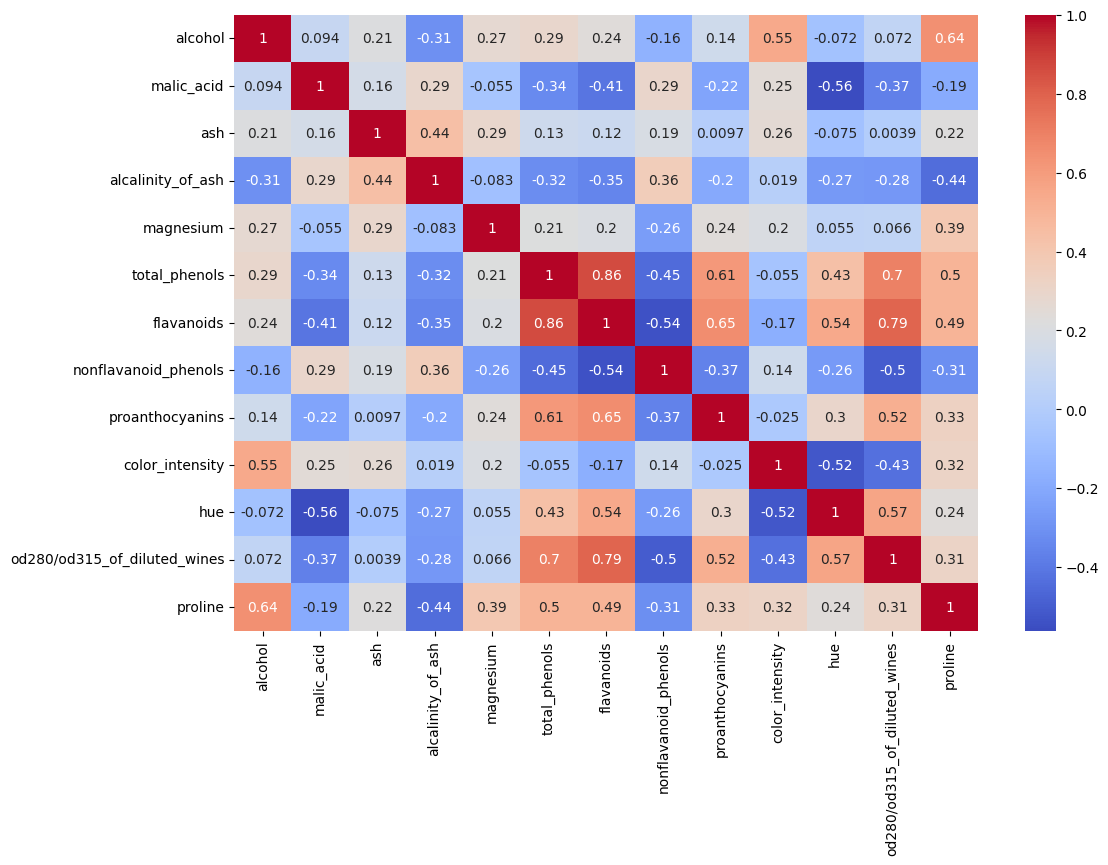

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm')
plt.show()

Look at:
```
total_phenols ↔ flavanoids

Correlation:

0.86

That's quite high.

And:

flavanoids ↔ od280/od315_of_diluted_wines

is:

0.79

Also:

total_phenols ↔ od280/od315_of_diluted_wines

is:

0.70

So several features are carrying related information.

Think about it like this:

total_phenols ─────┐
                   │
flavanoids ────────┼── Similar underlying information
                   │
od280/od315 ───────┘

They aren't identical, but they're related.


# 4. Now understand the problem we're trying to solve
```
We currently have:

13 features

Imagine we wanted to visualize every wine.

We could plot:

alcohol vs malic_acid

That's easy.

But what about all 13 features?

We can't make a normal human-friendly plot of:

13-dimensional data

Humans have once again encountered the limitations of their biological hardware.

So we'd like to transform:

13 dimensions
      ↓
2 dimensions

while preserving as much useful information as possible.

That's where PCA comes in.
```
# 5. Before PCA, one important distinction
```
Dimensionality Reduction ≠ PCA

These are not synonyms.

Dimensionality reduction is the broad concept.

It means:

Reduce the number of features/dimensions while trying to retain useful information.

There are many techniques:

Dimensionality Reduction
│
├── PCA
├── LDA
├── t-SNE
├── UMAP
└── others

PCA is one technique for dimensionality reduction.

So:

Dimensionality Reduction
        ↓
       PCA

not:

Dimensionality Reduction = PCA

That's an important distinction for interviews and exams.

# 6. Now let's scale the data

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [15]:
x_scaled.shape

(178, 13)

# 7. Let's prove that scaling worked

In [16]:
x_scaled.mean(axis=0)

array([ 7.84141790e-15,  2.44498554e-16, -4.05917497e-15, -7.11041712e-17,
       -2.49488320e-17, -1.95536471e-16,  9.44313292e-16, -4.17892936e-16,
       -1.54059038e-15, -4.12903170e-16,  1.39838203e-15,  2.12688793e-15,
       -6.98567296e-17])

In [17]:
x_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

So conceptually:
```
BEFORE SCALING

alcohol     → different scale
magnesium   → different scale
proline     → huge scale


             ↓ StandardScaler


AFTER SCALING

alcohol     → mean ≈ 0, std ≈ 1
magnesium   → mean ≈ 0, std ≈ 1
proline     → mean ≈ 0, std ≈ 1

Now each feature gets a fair chance to contribute to PCA.

One subtle but important thing

We are currently doing this:

X_scaled = scaler.fit_transform(x)

For learning PCA concepts, that's perfectly fine.

Later, when we build the actual ML model, we'll properly do:

Train data
   ↓
fit scaler
   ↓
transform train

Test data
   ↓
transform using SAME scaler

We don't want information from the test set leaking into the training process. That's called data leakage, and it is one of those delightful ways to make an ML model look smarter than it actually is.

```
1. Shape stayed the same

You got:

x_scaled.shape
(178, 13)

Before scaling:

178 rows × 13 features

After scaling:

178 rows × 13 features

So StandardScaler does not perform dimensionality reduction.

It only changes the scale.

2. Mean is approximately 0

You got numbers such as:

7.84e-15
2.44e-16
-4.05e-17
...

These are basically zero.

For example:

7.84e-15

means:

7.84 × 10⁻¹⁵

which is:

0.00000000000000784

So when you see:

mean ≈ 0

that's exactly what we wanted.

Why isn't Python displaying literally 0?

Because computers do floating-point calculations and accumulate tiny numerical errors. Mathematically, we treat those values as zero.

3. Standard deviation is 1

You got:

array([1., 1., 1., 1., ...])

So every feature now has:

Mean ≈ 0
Standard deviation ≈ 1

That's the standardization performed by:

$$ z = \frac{x-\mu}{\sigma} $$

Where:

\(x\) = original value
\(\mu\) = feature mean
\(\sigma\) = feature standard deviation
\(z\) = standardized value
Example

Suppose:

proline mean = 746
proline std  = 315

and one wine has:

proline = 1065

Standardization gives approximately:

$$ z = \frac{1065-746}{315} $$ $$ z \approx 1.01 $$

So instead of working with:

1065

PCA sees approximately:

1.01

This makes the features comparable.

```
4. Now comes the important part: PCA

We've established:

Original dataset
      ↓
178 × 13
      ↓
Different feature scales
      ↓
StandardScaler
      ↓
178 × 13
      ↓
Same number of dimensions

Now we're actually going to reduce those 13 dimensions.

Before writing the PCA code, understand the central idea.

Imagine our data in 2D

Suppose we only had:

Feature 1
Feature 2

We could plot every wine:

Feature 2
   ↑
   |              •
   |           •
   |        •
   |     •
   |   •
   | •
   +--------------------→ Feature 1

Notice the points aren't randomly scattered.

They roughly follow a diagonal direction.

PCA asks:

"Can I find a new axis that follows the direction where the data varies the most?"

Something like:

Feature 2
   ↑
   |             •
   |          •
   |       •
   |    •
   |  •
   | •
   +--------------------→ Feature 1
        ↗
       /
      /
   New axis

That new axis is the first Principal Component.

5. PC1

Principal Component 1, or PC1, is the direction in feature space along which the data has the maximum variance.

Think:

13 original features
        ↓
PCA finds direction of maximum variance
        ↓
             PC1

Then PCA finds another direction:

PC2

which captures the maximum remaining variance while being orthogonal/perpendicular to PC1.

Then:

PC3
PC4
PC5
...
PC13

So PCA transforms:

Original features

F1
F2
F3
...
F13

into:

Principal components

PC1
PC2
PC3
...
PC13

The crucial difference is that PCs are combinations of the original features.

PCA doesn't simply say:

"I'll keep alcohol, magnesium and proline and delete the rest."

Instead, it creates new axes from combinations of the original features.

# 6. Let's actually create PCA

Here's a very important trick.

Don't immediately choose n_components=2.

If we want to understand how much variance each component captures, let's initially calculate all 13 components.

In [18]:
from sklearn.decomposition import PCA

pca = PCA()

x_pca = pca.fit_transform(x_scaled)

In [19]:
x_pca.shape

(178, 13)

You should get:
```
(178, 13)

And this may look strange:

"Wait, Lospepos, we were trying to reduce dimensions. Why are we still at 13?"

Exactly.

We're doing this deliberately.

At this stage we're asking PCA:

"Calculate all principal components and tell me how much variance each one captures."

We haven't decided how many components to keep yet.

In [20]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

You'll get 13 numbers.
```
our exact values will come from the dataset.

These numbers are extremely important.

They tell us:

What percentage of the total variance is captured by each principal component.

For example, if:

PC1 = 0.36

that means:

PC1 captures ≈ 36% of the variance

If:

PC2 = 0.19

then:

PC2 captures ≈ 19%

Together:

PC1 + PC2
≈ 55%

So just two dimensions could potentially represent around 55% of the variation in the original 13-dimensional dataset.

That's the core idea behind PCA.

1. What does explained_variance_ratio_ mean?
```
This is one of the most important PCA concepts.

Each number tells us:

What proportion of the total variance in the original 13-dimensional data is captured by that principal component.

For example:

PC1 = 0.36198848

Convert it to percentage:

$$ 0.36198848 \times 100 = 36.20\% $$

So:

PC1 alone captures about 36.2% of the total variance.

Similarly:

PC2 = 0.1920749

means:

PC2 captures about 19.2%.

2. Let's make a table

Your PCA results become much easier to understand like this:

Component	Explained variance	Percentage
PC1	0.36199	36.20%
PC2	0.19207	19.21%
PC3	0.11124	11.12%
PC4	0.07069	7.07%
PC5	0.06563	6.56%
PC6	0.04936	4.94%
PC7	0.04239	4.24%
PC8	0.02681	2.68%
PC9	0.02222	2.22%
PC10	0.01930	1.93%
PC11	0.01737	1.74%
PC12	0.01298	1.30%
PC13	0.00795	0.80%

Notice what happened.

The first few components capture a lot of the variation.

3. PC1 + PC2

Let's calculate:

$$ 36.20 + 19.21 = 55.41\% $$

So if we keep only:

PC1
PC2

we retain approximately:

55.4% of the total variance.

We've gone from:

13 dimensions
       ↓
2 dimensions

while retaining roughly:

55.4% of the variance

That's already pretty impressive.

But we shouldn't blindly say:

"55% is enough."

Maybe it is. Maybe it isn't.

That's the decision PCA helps us investigate.

4. PC1 + PC2 + PC3

Now:

$$ 36.20 + 19.21 + 11.12 $$

≈ 66.5%

So:

3 components
      ↓
≈ 66.5% variance
5. First 5 components

Let's calculate:

$$ 36.20 + 19.21 + 11.12 + 7.07 + 6.56 $$

≈ 80.2%

So:

13 original dimensions
        ↓
5 principal components
        ↓
≈ 80.2% variance retained

This is exactly the sort of trade-off we're looking for.

We're potentially throwing away 8 dimensions while retaining about 80% of the variance.

6. But here's an important question

How do we choose the number of components?

We have several approaches.

One of the most famous is:

📉 Scree Plot

The Scree plot plots:

Component number
        vs
Explained variance

So let's make one.

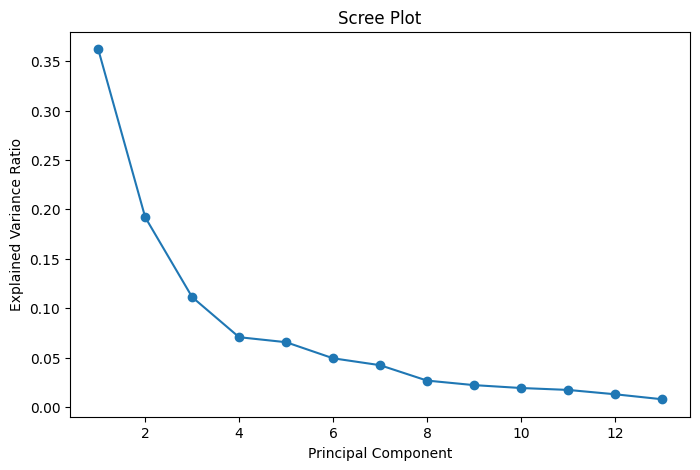

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

plt.show()

You'll get something roughly like:
```
Explained
Variance
   |
0.36| ●
    |  \
0.30|   \
    |    \
0.20|     ●
    |      \
0.10|       ●
    |         ●
0.05|           ● ●
    |              ●...
    |
    +-------------------------
      1  2  3  4  5  6 ... 13
             Components
What are we looking for?

We're looking for an elbow.

Something like:

PC1 ●
     \
      \
PC2    ●
        \
PC3      ●
          \
PC4        ●
            \
PC5          ●
              \________

The idea is:

Before the elbow, each additional component gives us a relatively large amount of new information.

After the elbow, additional components give us progressively smaller amounts.

That's why it's called a Scree plot. The word comes from loose rock/debris piled at the base of a cliff. Scientists apparently decided that naming statistical plots after rubble was perfectly reasonable.

7. But don't confuse two different things

This is very important.

Scree plot

Looks at the individual contribution:

PC1 → 36.2%
PC2 → 19.2%
PC3 → 11.1%
...
Cumulative explained variance

Looks at the total accumulated contribution:

PC1                 → 36.2%
PC1 + PC2           → 55.4%
PC1 + PC2 + PC3     → 66.5%
...

We'll use both.

# 8. Let's calculate cumulative variance

In [24]:
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

cumulative_variance

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
       0.97906553, 0.99204785, 1.        ])

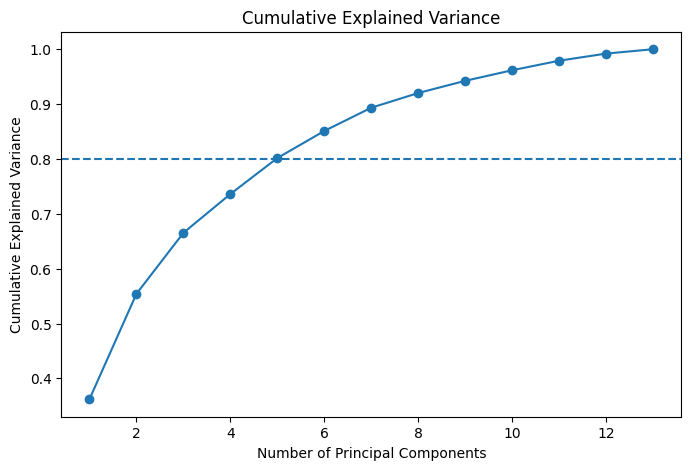

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')

plt.axhline(y=0.80, linestyle='--')

plt.show()

This graph will help us answer:
```
How many principal components do I need to retain 80% of the variance?

From your numbers, we're going to find that it's around 5 components.

One thing I want you to notice

We're gradually moving from:

13 original features

to:

PC1
PC2
PC3
...
PC13

But PCA hasn't magically "selected the best five original features."

Instead:

13 original features
        ↓
PCA
        ↓
13 new principal components
        ↓
keep first 5
        ↓
5-dimensional representation

That's a fundamental PCA concept.

# Step 8: Understand PCA Loadings
```
Remember, PCA created new features:

Original features
13 columns
     ↓
    PCA
     ↓
PC1, PC2, PC3, ... PC13

But what is PC1?

PC1 is a weighted combination of the original features:

$$ PC1 = w_1X_1+w_2X_2+w_3X_3+\cdots+w_{13}X_{13} $$

Those \(w\)'s are the loadings.

So loadings tell us:

How strongly each original feature contributes to each principal component.

In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(1,14)],
    index=x.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539,-0.056396,0.396139,-0.508619,0.211605,-0.225917,-0.266286,0.014970
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,-0.309080,0.076486,0.121696,0.025964
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475,-0.149171,-0.170260,0.307694,-0.027125,-0.498691,-0.049622,-0.141218
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825,-0.286969,0.427970,-0.200449,0.052799,0.479314,-0.055743,0.091683
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144,0.322883,-0.156361,-0.271403,0.067870,0.071289,0.062220,0.056774
total_phenols,0.394661,0.065040,0.146179,0.198068,-0.149318,-0.084122,-0.027925,-0.405934,-0.286035,-0.320131,0.304341,-0.303882,-0.463908
flavanoids,0.422934,-0.003360,0.150682,0.152295,-0.109026,-0.018920,-0.060685,-0.187245,-0.049578,-0.163151,-0.025694,-0.042899,0.832257
nonflavanoid_phenols,-0.298533,0.028779,0.170368,-0.203301,-0.500703,-0.258594,0.595447,-0.233285,-0.195501,0.215535,0.116896,0.042352,0.114040
proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860,-0.533795,0.372139,0.368227,0.209145,0.134184,-0.237363,-0.095553,-0.116917
color_intensity,-0.088617,0.529996,-0.137306,0.065926,-0.076437,-0.418644,-0.227712,-0.033797,-0.056218,-0.290775,0.031839,0.604222,-0.011993


Why .T?
```
pca.components_ has the shape:

(13, 13)

Rows represent principal components.

We transpose it:

.T

so that:

Rows    → original features
Columns → principal components

which makes the table much easier for humans to read.

# Step 9: Find the strongest contributors to PC1

In [29]:
loadings['PC1'].sort_values()

# You'll see positive and negative values.

nonflavanoid_phenols           -0.298533
malic_acid                     -0.245188
alcalinity_of_ash              -0.239320
color_intensity                -0.088617
ash                            -0.002051
magnesium                       0.141992
alcohol                         0.144329
proline                         0.286752
hue                             0.296715
proanthocyanins                 0.313429
od280/od315_of_diluted_wines    0.376167
total_phenols                   0.394661
flavanoids                      0.422934
Name: PC1, dtype: float64

The sign itself isn't usually the important part.
```
The magnitude is.

So a loading of:

-0.45

has a stronger contribution than:

0.05

because:

|-0.45| > |0.05|

To see the strongest contributors regardless of direction:

loadings['PC1'].abs().sort_values(ascending=False)

That gives us:

Feature                    |Loading|
flavanoids                  ...
total_phenols               ...
od280/od315...              ...
...

# Step 10: Let's visualize the loadings

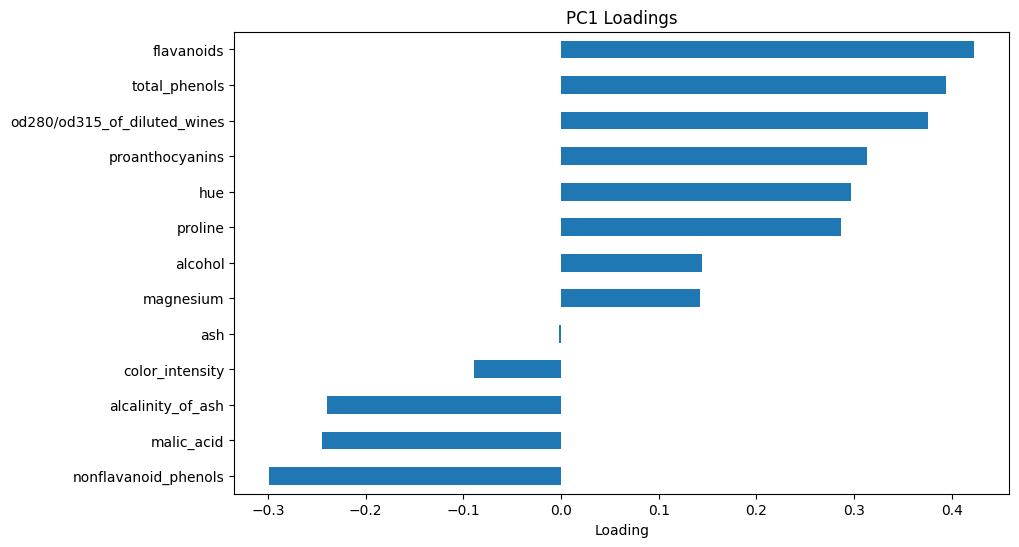

In [30]:
plt.figure(figsize=(10, 6))

loadings['PC1'].sort_values().plot(kind='barh')

plt.xlabel('Loading')
plt.title('PC1 Loadings')

plt.show()

Now you'll visually see:
```
                 PC1
                 │
Feature A    █████████
Feature B    ██████
Feature C    ███
Feature D    ▏
Feature E    ████████

This answers:

Which original features are responsible for PC1?

Step 11: One subtle thing about loadings

Suppose you get:

Feature A = +0.40
Feature B = +0.38
Feature C = -0.42

This means PC1 is influenced strongly by all three.

The positive and negative signs represent direction in the principal-component coordinate system.

Don't interpret:

positive = good
negative = bad

That would be inventing meaning that PCA never promised us.

Also, the overall sign of a PCA component can be flipped without changing the underlying solution. So focus primarily on the relative magnitudes and relationships.

# Step 12: Now we're ready for the actual dimensionality reduction

Until now, we've calculated all 13 PCs so we could understand them.

Now let's say we decide to keep 5 components, because they capture about 80% of the variance.

Create PCA again:

In [34]:
pca_5 = PCA(n_components=5)

X_pca_5 = pca_5.fit_transform(x_scaled)

In [38]:
X_pca_5.shape

(178, 5)

And this is actual dimensionality reduction:
```
BEFORE

178 × 13
      ↓
     PCA
      ↓
AFTER

178 × 5

We've reduced:

13 dimensions → 5 dimensions

while retaining roughly 80% of the variance.

That's a reduction of:

8 dimensions

or about:

61.5% fewer dimensions

# Step 13: Check exactly how much variance we retained

In [40]:
pca_5.explained_variance_ratio_

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294])

In [41]:
pca_5.explained_variance_ratio_.sum()

np.float64(0.8016229275554788)

So you can literally say:

"I reduced the dataset from 13 dimensions to 5 dimensions while retaining approximately 80% of the variance."

That's a proper PCA statement, rather than the usual "PCA reduced my data because machine learning."

# Step 14: Visualize the 13-dimensional data in 2D
```
We have already created:

pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)

But for visualization, we'll specifically use PC1 and PC2.

Why?

Because they capture the largest amount of variance:

PC1 → 36.20%
PC2 → 19.21%
----------------
Together → 55.41%

So we're taking 13 dimensions and looking at them through the first two principal-component axes.

In [43]:
pca_df = pd.DataFrame(
    X_pca_5,
    columns=[f'PC{i}' for i in range(1, 6)]
)

pca_df['Target'] = y.values

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,Target
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0
2,2.516740,1.031151,0.982819,0.724902,-0.251033,0
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,0
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0


# Step 15: Plot PC1 vs PC2

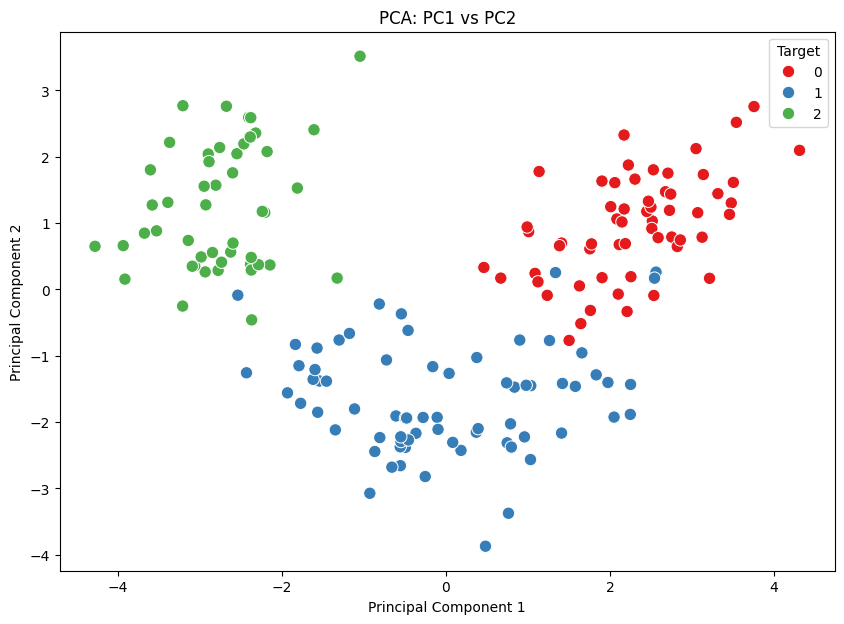

In [44]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Target',
    palette='Set1',
    s=80
)

plt.title('PCA: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

Each dot represents one wine.
```
Before PCA, each wine was represented by:

13 numbers

For example:

Wine #1
[alcohol, malic_acid, ash, ..., proline]

After PCA, that same wine is represented by:

[PC1, PC2, PC3, PC4, PC5]

And for this particular visualization, we're only looking at:

[PC1, PC2]

So we've effectively taken:

13-dimensional wine
       ↓
     PCA
       ↓
2-dimensional representation

# Step 16: Why do the classes matter?
```
Remembr, PCA doesn't know anything about Target.

This is a crucial concept.

When we did:

pca.fit_transform(X_scaled)

we gave PCA only:

X_scaled

We did not give it:

y

Therefore PCA doesn't know:

"This wine is Class 0."

"This wine is Class 1."

PCA simply finds directions of maximum variance.

Then we color the resulting points using Target.

This makes PCA an unsupervised dimensionality-reduction technique.

X → PCA → PCs

y → used only to color/evaluate afterward

That's a very useful distinction.

Step 17: Let's quantify the visualization

Our PC1 + PC2 representation retains:

$$ 0.36198848 + 0.1920749 $$

≈

55.41%

of the total variance.

So our 2D plot isn't representing 100% of the original information.

It's representing about:

13 dimensions
      ↓
2 dimensions
      ↓
55.4% variance retained

That's why PCA visualization should be interpreted as a compressed view, not a perfect copy of the original dataset.

# Step 18: Now compare different numbers of components

This is where the practical decision becomes interesting.

Let's calculate cumulative variance for every possible number of components.

In [45]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

variance_table = pd.DataFrame({
    'Components': range(1, 14),
    'Cumulative Variance': cumulative_variance
})

variance_table

,Components,Cumulative Variance
0,1,0.361988
1,2,0.554063
2,3,0.665300
3,4,0.735990
4,5,0.801623
5,6,0.850981
6,7,0.893368
7,8,0.920175
8,9,0.942397
9,10,0.961697


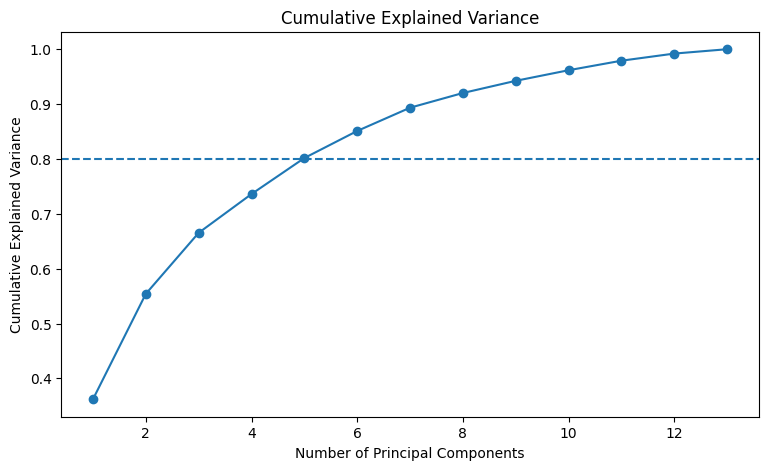

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    variance_table['Components'],
    variance_table['Cumulative Variance'],
    marker='o'
)

plt.axhline(
    y=0.80,
    linestyle='--'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')

plt.show()

# Step 19: Choosing the number of components
```
Suppose our requirement is:

Keep at least 80% of the variance.

From your results:

PC1       → 36.20%
PC1-2     → 55.41%
PC1-3     → 66.53%
PC1-4     → 73.60%
PC1-5     → 80.16%

Therefore:

5 components

is the first point where we cross approximately 80%.

So:

13 dimensions
     ↓
5 dimensions

while retaining:

≈ 80.16% variance

That's a very reasonable dimensionality-reduction choice if 80% is our chosen retention target.

But there isn't a universal magical rule saying "PCA always needs 5 components." The appropriate number depends on the application, model performance, computational goals, and acceptable information loss.

Step 20: Scree plot vs cumulative variance

You now have two different tools.

Scree plot

Looks at:

Individual component
        ↓
How much variance does it explain?

Your first components:

PC1 → 36.2%
PC2 → 19.2%
PC3 → 11.1%
PC4 → 7.1%
PC5 → 6.6%
...

It helps identify an elbow where additional components start contributing relatively little.

Cumulative variance plot

Looks at:

How much total variance have I retained?

For example:

5 PCs → 80.16%
8 PCs → 92.02%
10 PCs → 96.17%

So the two plots answer slightly different questions:

Scree Plot
    ↓
Where does the improvement start slowing down?

Cumulative Variance
    ↓
How many components do I need to retain X%?
Step 21: The really important practical test

Now we're going to answer the question:

Does PCA actually help an ML model?

Because reducing dimensions just for the aesthetic pleasure of having fewer columns isn't particularly useful.

We'll compare:

Model A
13 original features
       ↓
ML model

against:

Model B
13 features
     ↓
Scaling
     ↓
PCA
     ↓
5 components
     ↓
ML model

For this we'll use Logistic Regression.

First, split the data properly:

In [49]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Why stratify=y?
```
We have three classes:

Class 0
Class 1
Class 2

stratify=y tries to preserve approximately the same class proportions in both training and test sets.

Then scale correctly

This time we're going to do it the proper ML way.

In [52]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Notice:
```
TRAIN
fit_transform()

but:

TEST
transform()

We do not fit the scaler on the test set.

# Model without PCA

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_original = LogisticRegression(max_iter=5000)

model_original.fit(x_train_scaled, y_train)

y_pred_original = model_original.predict(x_test_scaled)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

accuracy_original

0.9722222222222222

# Model with PCA

In [63]:
pca = PCA(n_components=5)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [65]:
model_pca = LogisticRegression(max_iter=5000)

model_pca.fit(x_train_pca, y_train)

y_pred_pca = model_pca.predict(x_test_pca)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

accuracy_pca

0.9722222222222222